In [1]:
import mpmath as mp
import numpy as np
from scipy.optimize import curve_fit

import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
N = 50000
mp.mp.dps = N 
num = str(mp.pi)

In [3]:
num = num.replace(".", "")

In [4]:
num_arr = [int(i) for i in num]

In [5]:
counts = np.bincount(num_arr)
counts

array([5033, 5054, 4867, 4948, 5011, 5052, 5018, 4977, 5030, 5010])

In [6]:
f = counts/N

In [7]:
f

array([0.10066, 0.10108, 0.09734, 0.09896, 0.10022, 0.10104, 0.10036,
       0.09954, 0.1006 , 0.1002 ])

In [8]:
f.shape
print(f)

[0.10066 0.10108 0.09734 0.09896 0.10022 0.10104 0.10036 0.09954 0.1006
 0.1002 ]


<BarContainer object of 10 artists>

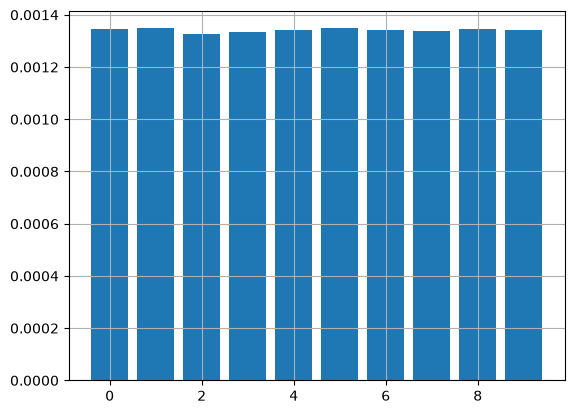

In [9]:
sigma = np.sqrt(f*(1 - f)/N)
plt.grid()
plt.bar(x = np.linspace(0,9,10), height= sigma)

## Equiprobability Hypothesis

In [10]:
d = np.arange(0,9,1)
d = np.linspace(0,9,10)
print(d)

[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]


In [11]:
def f_linear_model(d, alpha, beta):
    return (alpha/10.0) + (beta * d)

popt, c = curve_fit(f_linear_model, d, f, p0= (1.0, 0.0), sigma = sigma, absolute_sigma= True)

In [12]:
c

array([[ 6.21800108e-05, -9.82692851e-07],
       [-9.82692851e-07,  2.18570201e-08]])

### Best Fit parameters Chi-squared 

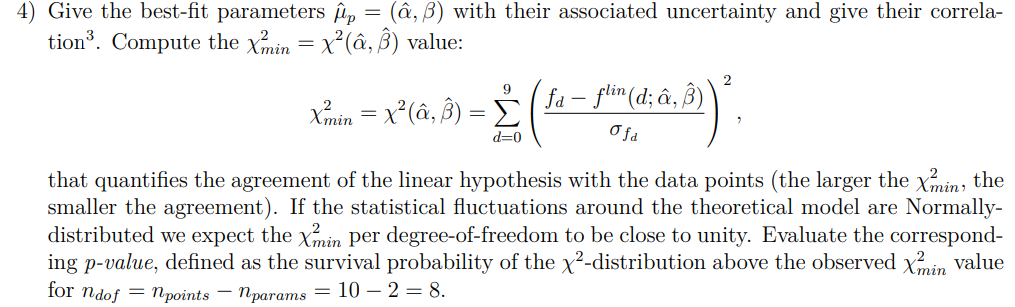

In [13]:
def f_linear_model(d, alpha, beta):
    return (alpha/10.0) + (beta * d)

p0= (1.0, 0.0)

popt, c = curve_fit(f_linear_model, d, f, p0= (1.0, 0.0), sigma = sigma, absolute_sigma= True)
print(f"Best Values: {popt}")
print(f"Covariance Matrix: {c}")

Best Values: [9.97457284e-01 5.42204798e-05]
Covariance Matrix: [[ 6.21800108e-05 -9.82692851e-07]
 [-9.82692851e-07  2.18570201e-08]]


In [14]:
print(f"Alpha : {popt[0]} \u00B1 {c[0,0]}")
print(f"Beta : {popt[1]} \u00B1 {c[1,1]}")

Alpha : 0.9974572840285697 ± 6.218001075831387e-05
Beta : 5.4220479773459235e-05 ± 2.1857020118242075e-08


Correlation

In [15]:
rho = c[0,1]/(np.sqrt(c[0,0] * c[1,1]))
rho


np.float64(-0.842940507178298)

χ²_min

In [16]:
chi_2_min = np.sum(((f - f_linear_model(d, *popt))/sigma) ** 2)
n_points = len(d)
n_params = len(popt)
n_dof = n_points - n_params

In [17]:
print(chi_2_min/n_dof)

0.8016738400063946


p-value

In [18]:
from scipy.stats import chi2

In [19]:
pval = chi2.sf(chi_2_min, n_dof)                  # survival function = 1 - cdf
pval

np.float64(0.6010295453203767)

### Procedural (function after function)
Not a great fan of this one 

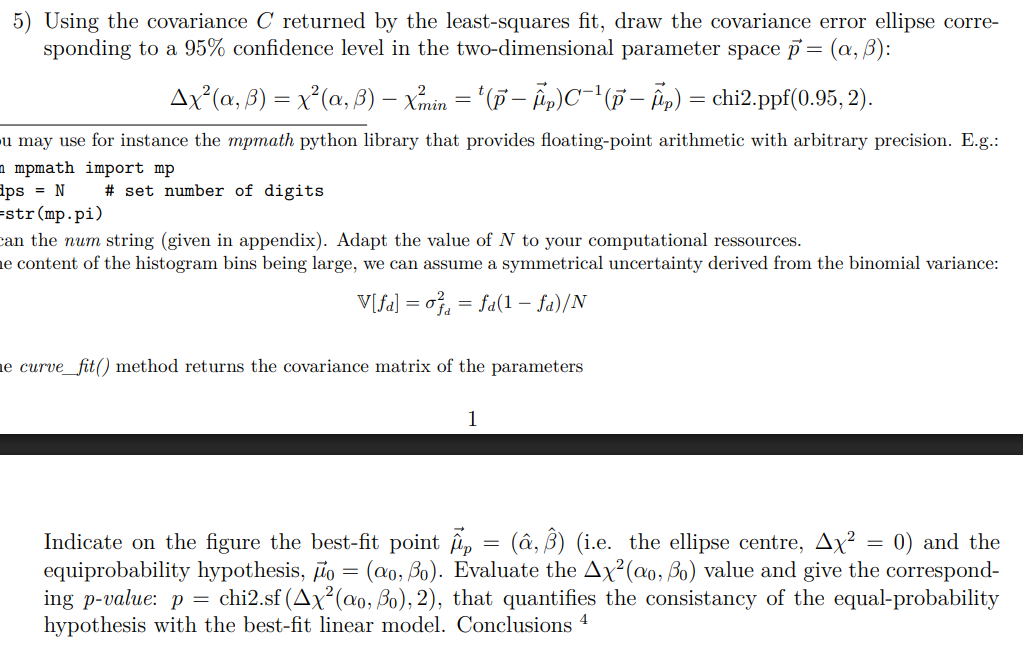

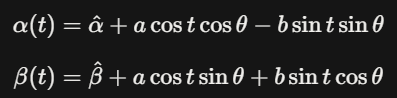

Numpy Linear algebra module eigh function to return eigen values and eigen vectors  

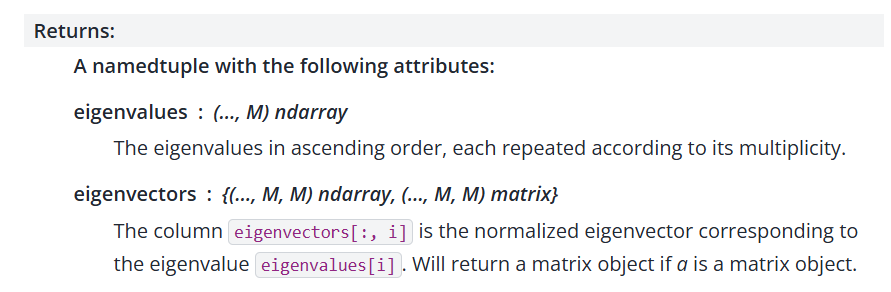

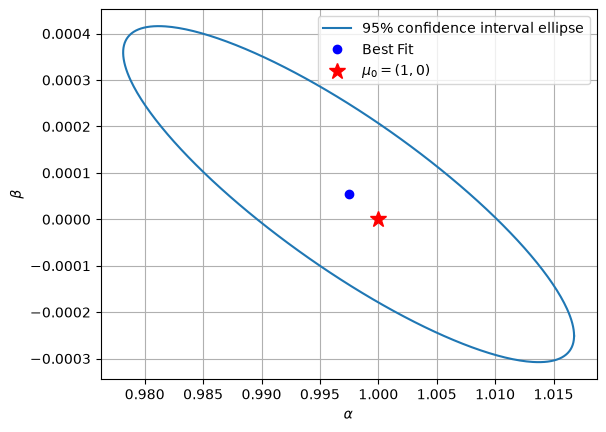

In [20]:
k = chi2.ppf(0.95, 2)

eig_val, eig_vec = np.linalg.eigh(c)

a = np.sqrt(k * eig_val[1])   # long semi-axis, along theta
b = np.sqrt(k * eig_val[0])   # short semi-axis

theta = 1/2 * np.arctan2(2 * c[0,1],c[0,0] - c[1,1])

t = np.linspace(0, 2* np.pi, 400)

alpha_t = popt[0] + (a * np.cos(t) * np.cos(theta)) - (b * np.sin(t) * np.sin(theta))    # defining the Parametric function
beta_t = popt[1] + (a * np.cos(t) * np.sin(theta)) + (b * np.sin(t) * np.cos(theta))

plt.grid()
plt.plot(alpha_t, beta_t, label = r"95% confidence interval ellipse")
plt.plot(*popt,"bo", label = "Best Fit")
plt.plot(1.0, 0.0, "r*", ms=12, label=r"$\mu_0=(1,0)$")
plt.xlabel(r"$\alpha$")
plt.ylabel(r"$\beta$")
plt.legend()


In [21]:
def del_chi_2(alpha, beta):
    p_vector = np.array([alpha, beta])
    u_p = popt

    return np.transpose(p_vector - u_p) @ np.linalg.inv(c) @ (p_vector - u_p)

In [22]:
del_chi_2(*p0)

np.float64(0.13511627391856565)

In [23]:
p_value_p0 = chi2.sf(del_chi_2(*p0), 2)
p_value_p0

np.float64(0.9346733799682089)

In [24]:
N = 50000
num = str(mp.e)

def constant_frequency(num, N):
    mp.mp.dps = N 
    num = num.replace(".", "")
    num_arr = [int(i) for i in num]
    print(num_arr)
    counts = np.bincount(num_arr)

    print(counts)

    f = counts/N

    sigma = np.sqrt(f*(1 - f)/N)

    return f, sigma

# plt.bar(x = d, height= constant_frequency(num, N))

In [25]:
def fitting(num, N):

    popt, c = curve_fit(f_linear_model, d, constant_frequency(num, N), p0= (1.0, 0.0), sigma = sigma, absolute_sigma= True)

    return popt, c

In [26]:
p0= (1.0, 0.0)

In [27]:
def corr_coeff(c):
    rho = c[0,1]/(np.sqrt(c[0,0] * c[1,1]))

    return rho

In [28]:
def chi_2_min_func(f, num, N):

    d = np.linspace(0,9,10)
    sigma = constant_frequency(num, N)[1]
    chi_2_min = np.sum(((f - f_linear_model(d, *popt))/sigma) ** 2)
    
    n_points = len(d)
    n_params = len(popt)
    n_dof = n_points - n_params

    return chi_2_min, n_dof

In [29]:
def ellipse():
    k = chi2.ppf(0.95, 2)

    eig_val, eig_vec = np.linalg.eigh(c)

    a = np.sqrt(k * eig_val[1])   # long semi-axis, along theta
    b = np.sqrt(k * eig_val[0])   # short semi-axis

    theta = 1/2 * np.arctan2(2 * c[0,1],c[0,0] - c[1,1])

    t = np.linspace(0, 2* np.pi, 400)

    alpha_t = popt[0] + (a * np.cos(t) * np.cos(theta)) - (b * np.sin(t) * np.sin(theta))
    beta_t = popt[1] + (a * np.cos(t) * np.sin(theta)) + (b * np.sin(t) * np.cos(theta))

    plt.grid()
    plt.plot(alpha_t, beta_t, label = r"95% confidence interval ellipse")
    plt.plot(*popt,"bo", label = "Best Fit")
    plt.plot(1.0, 0.0, "r*", ms=12, label=r"$\mu_0=(1,0)$")
    plt.xlabel(r"$\alpha$")
    plt.ylabel(r"$\beta$")
    plt.legend()


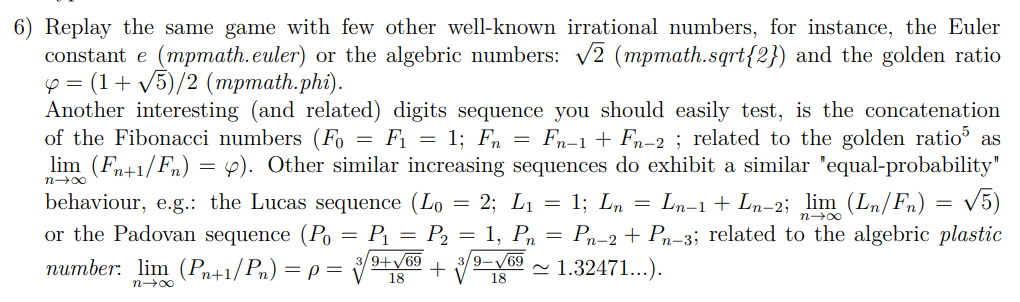

### I am just going to use Object oriented programing for this, I am really tired of definining functions again and again 🫩​

Also, comments and docstrings written by claud (I am not doing all that)

=== pi (N = 50000) ===
alpha = 0.99746 +/- 0.00789
beta  = 5.422e-05 +/- 1.478e-04
correlation(alpha, beta) = -0.8429
chi2_min = 6.413  (ndof = 8, chi2/ndof = 0.802)
p-value (fit quality)      = 0.6010
Delta chi2(mu0)            = 0.135
p-value (mu0 consistency)  = 0.9347

=== e (N = 50000) ===
alpha = 1.00230 +/- 0.00788
beta  = -5.394e-05 +/- 1.473e-04
correlation(alpha, beta) = -0.8425
chi2_min = 7.781  (ndof = 8, chi2/ndof = 0.973)
p-value (fit quality)      = 0.4552
Delta chi2(mu0)            = 0.135
p-value (mu0 consistency)  = 0.9348

=== sqrt2 (N = 50000) ===
alpha = 1.00031 +/- 0.00788
beta  = -9.487e-06 +/- 1.475e-04
correlation(alpha, beta) = -0.8427
chi2_min = 7.280  (ndof = 8, chi2/ndof = 0.910)
p-value (fit quality)      = 0.5068
Delta chi2(mu0)            = 0.005
p-value (mu0 consistency)  = 0.9976

=== phi (N = 50000) ===
alpha = 1.00153 +/- 0.00789
beta  = -3.513e-05 +/- 1.478e-04
correlation(alpha, beta) = -0.8433
chi2_min = 2.895  (ndof = 8, chi2/ndof = 0.362)
p-valu

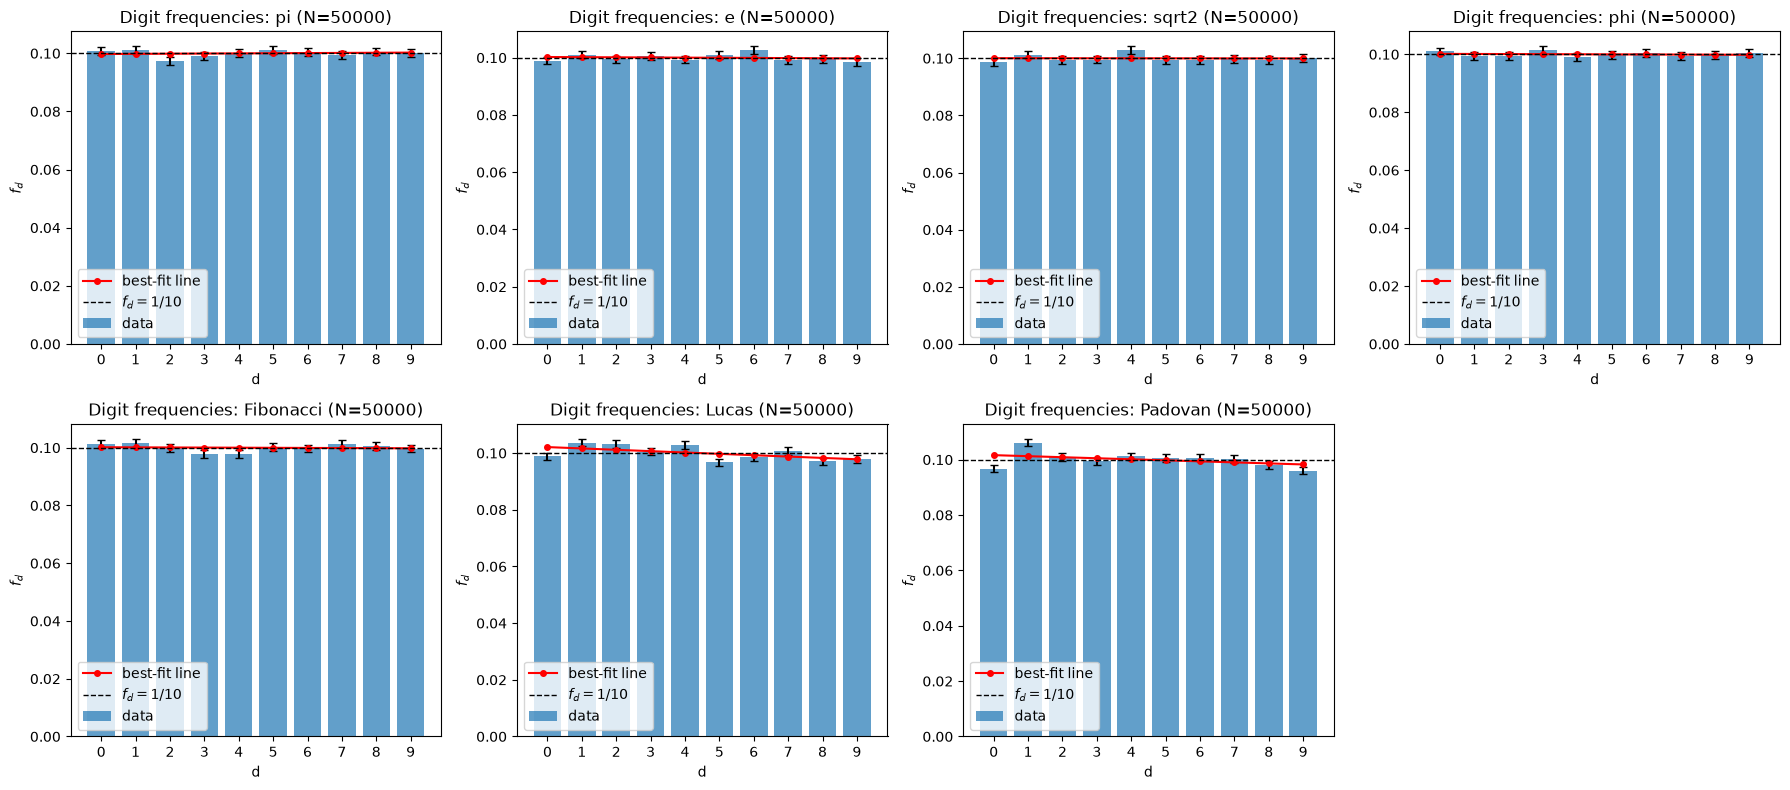

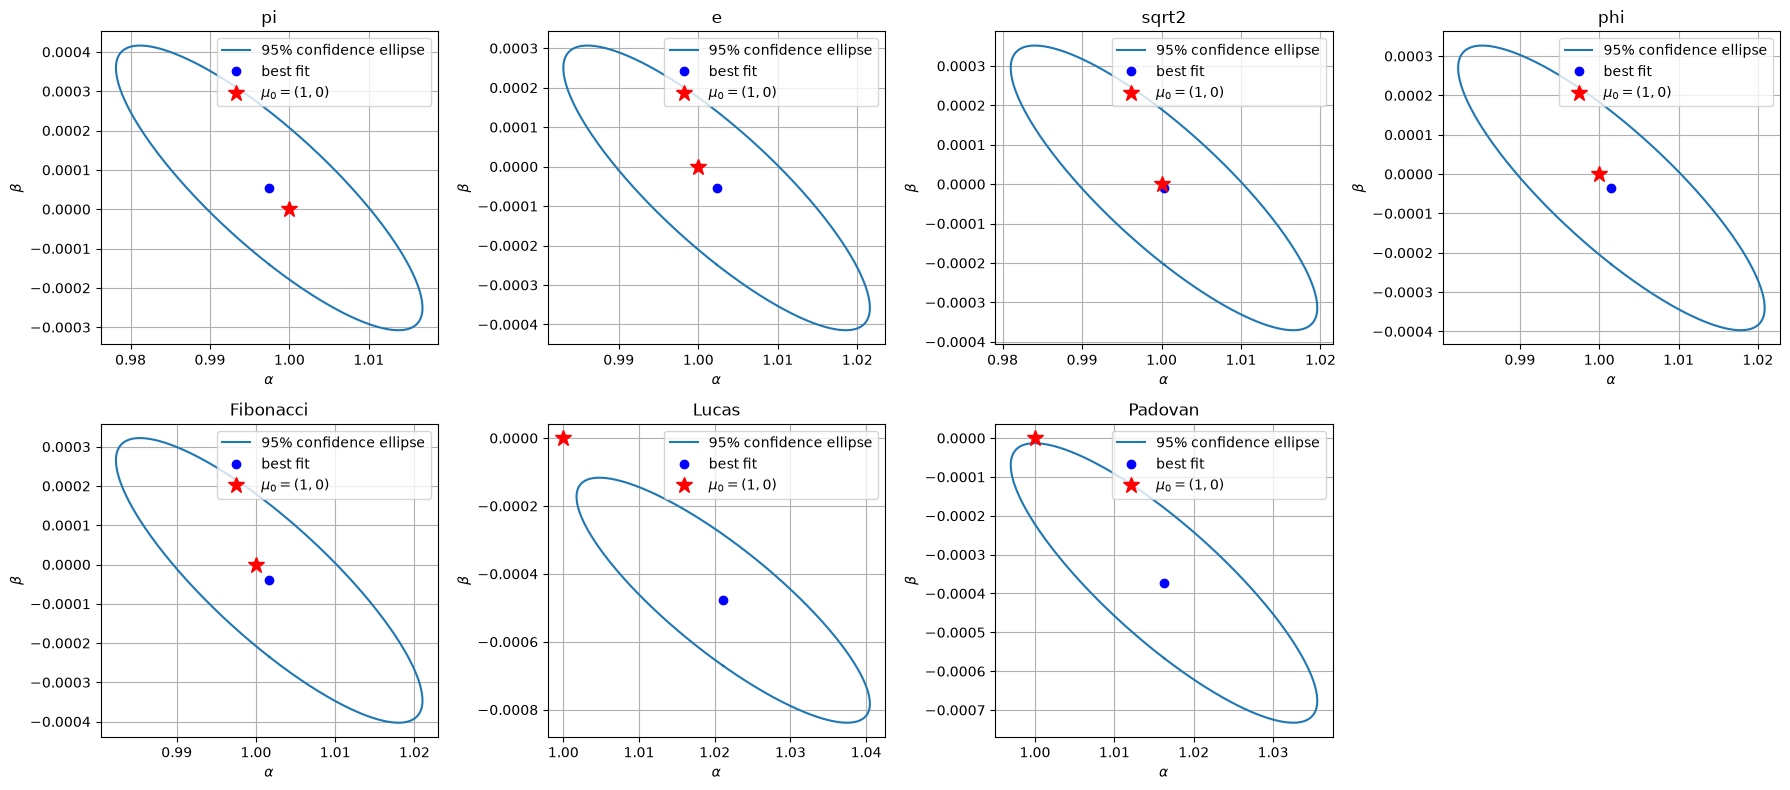

In [30]:
# Digit sources: classes that know how to produce a list of digits

class DigitSource:
    """Anything that can produce a string of N decimal digits.

    Base class: stores a name and defines the interface (digits) that
    every subclass must provide.
    """

    def __init__(self, name):
        self.name = name        # label used in plot titles and reports

    def digits(self, N):
        """Return a numpy int array containing exactly N digits."""
        raise NotImplementedError("Subclasses must implement digits()")


class MpmathConstantSource(DigitSource):
    """Digits of an mpmath constant, e.g. MpmathConstantSource('e', lambda: mp.e).

    The constant is passed as a function (lambda) so that it is only evaluated
    once the precision has been set inside digits().
    """

    def __init__(self, name, constant_factory):
        super().__init__(name)
        self.constant_factory = constant_factory   # callable evaluated AFTER setting precision

    def digits(self, N):
        """Return the first N digits of the constant (the decimal point is dropped)."""
        mp.mp.dps = N + 10                          # extra guard digits; precision set BEFORE evaluating
        s = mp.nstr(self.constant_factory(), N + 5, strip_zeros=False)   # number as a string
        s = s.replace(".", "")                      # remove the decimal point
        return np.array([int(c) for c in s[:N]])    # keep exactly N digits as integers


class SequenceSource(DigitSource):
    
    """Digits of the concatenation of an increasing integer sequence.

    Example: Fibonacci 1, 1, 2, 3, 5, 8, 13, ... -> digits 1,1,2,3,5,8,1,3,...
    The sequence is defined by its first terms and a recurrence rule.
    """

    def __init__(self, name, initial_terms, recurrence):
        super().__init__(name)
        self.initial_terms = list(initial_terms)
        self.recurrence = recurrence                # function: list_of_terms -> next term

    def digits(self, N):
        """Generate terms until at least N digits exist, then keep the first N."""
        terms = list(self.initial_terms)
        s = "".join(str(t) for t in terms)          # start with the initial terms glued together
        while len(s) < N:
            terms.append(self.recurrence(terms))    # compute the next term
            s += str(terms[-1])                     # append its digits
        return np.array([int(c) for c in s[:N]])

    # helpful constructors: ready-made sequences, e.g. SequenceSource.fibonacci()
    @classmethod
    def fibonacci(cls):
        """Fibonacci: F0 = F1 = 1, Fn = Fn-1 + Fn-2."""
        return cls("Fibonacci", [1, 1], lambda t: t[-1] + t[-2])

    @classmethod
    def lucas(cls):
        """Lucas: L0 = 2, L1 = 1, Ln = Ln-1 + Ln-2."""
        return cls("Lucas", [2, 1], lambda t: t[-1] + t[-2])

    @classmethod
    def padovan(cls):
        """Padovan: P0 = P1 = P2 = 1, Pn = Pn-2 + Pn-3."""
        return cls("Padovan", [1, 1, 1], lambda t: t[-2] + t[-3])


# Analyzing

class DigitFrequencyAnalyzer:
    """Frequencies + linear fit f(d) = alpha/10 + beta*d + chi2 + confidence ellipse.

    Usage: DigitFrequencyAnalyzer(source, N).run(), then .report(),
    .plot_histogram() and .plot_ellipse().
    """

    MU0 = np.array([1.0, 0.0])                      # equiprobability hypothesis

    def __init__(self, source, N=50000):
        self.source = source        # a DigitSource object
        self.N = N                  # number of digits to analyze
        self.d = np.arange(10)      # the digits 0..9

        # results filled by the methods below
        self.f = self.sigma = None                  # frequencies and their errors
        self.popt = self.cov = None                 # best-fit parameters and covariance matrix
        self.chi2_min = self.n_dof = self.p_value = None

    @staticmethod
    def linear_model(d, alpha, beta):
        """Model to fit: alpha/10 + beta*d (equiprobability means alpha=1, beta=0)."""
        return alpha / 10.0 + beta * d

    def compute_frequencies(self):
        """Count digits and return the frequencies f_d with binomial errors sigma_d."""
        digits = self.source.digits(self.N)
        counts = np.bincount(digits, minlength=10)  # occurrences of each digit 0-9
        self.f = counts / len(digits)
        self.sigma = np.sqrt(self.f * (1 - self.f) / len(digits))   # binomial error
        return self.f, self.sigma

    def fit(self):
        """Least-squares fit of the linear model; returns best-fit values and covariance."""
        if self.f is None:                          # make sure frequencies exist first
            self.compute_frequencies()
        self.popt, self.cov = curve_fit(
            self.linear_model, self.d, self.f,
            p0=self.MU0, sigma=self.sigma, absolute_sigma=True,   # errors are real, not just weights
        )
        return self.popt, self.cov

    @property
    def param_errors(self):
        """1-sigma uncertainties on (alpha, beta): square roots of the covariance diagonal."""
        return np.sqrt(np.diag(self.cov))

    @property
    def correlation(self):
        """Correlation coefficient between alpha and beta."""
        return self.cov[0, 1] / np.sqrt(self.cov[0, 0] * self.cov[1, 1])

    def compute_chi2(self):

        """Compute chi2_min, degrees of freedom and the p-value of the fit."""
        
        residuals = (self.f - self.linear_model(self.d, *self.popt)) / self.sigma
        self.chi2_min = np.sum(residuals ** 2)
        self.n_dof = len(self.d) - len(self.popt)   # 10 points - 2 parameters = 8
        self.p_value = chi2.sf(self.chi2_min, self.n_dof)   # survival function = P(chi2 > observed)
        return self.chi2_min, self.n_dof, self.p_value

    def delta_chi2(self, alpha, beta):
        """Delta chi2 = (p - p_hat)^T C^-1 (p - p_hat)."""
        diff = np.array([alpha, beta]) - self.popt  # distance from the best fit
        return diff @ np.linalg.inv(self.cov) @ diff

    def mu0_consistency(self):
        """Delta chi2 and p-value (2 dof) of the equiprobability point mu0."""
        dchi2 = self.delta_chi2(*self.MU0)
        return dchi2, chi2.sf(dchi2, 2)

    def run(self):
        """Run the whole pipeline."""
        self.compute_frequencies()
        self.fit()
        self.compute_chi2()

        return self                                 # returning self allows chaining: Analyzer(...).run()

    # plotting
    def plot_histogram(self, ax=None):
        """Bar chart of f_d with error bars, the best-fit line and the 1/10 level."""
        ax = ax                        # use current axes if none is given
        ax.bar(self.d, self.f, yerr=self.sigma, capsize=3, alpha=0.7, label="data")
        ax.plot(self.d, self.linear_model(self.d, *self.popt), "r-o", ms=4, label="best-fit line")
        ax.axhline(0.1, color="k", ls="--", lw=1, label=r"$f_d = 1/10$")
        ax.set_xticks(self.d)
        ax.set_xlabel("d")
        ax.set_ylabel(r"$f_d$")
        ax.set_title(f"Digit frequencies: {self.source.name} (N={self.N})")
        ax.legend()
        return ax

    # contructing ellipse
    def ellipse_points(self, cl=0.95, n=400):
        """Return (alpha, beta) coordinates of the confidence ellipse at level cl.

        The ellipse axes come from the eigenvectors/eigenvalues of the covariance
        matrix; its size is set by the chi2 quantile for 2 parameters.
        """
        k = chi2.ppf(cl, 2)                         # Delta chi2 threshold (about 5.99 for 95%)
        eigval, eigvec = np.linalg.eigh(self.cov)               # eigenvectors = ellipse axes
        t = np.linspace(0, 2 * np.pi, n)
        unit_circle = np.vstack([np.cos(t), np.sin(t)])
        # stretch the unit circle along the axes, rotate it, then shift to the best fit
        pts = eigvec @ (np.sqrt(k * eigval)[:, None] * unit_circle)
        return self.popt[0] + pts[0], self.popt[1] + pts[1]

    def plot_ellipse(self, ax=None, cl=0.95):
        """Plot the confidence ellipse, the best-fit point and the hypothesis mu0."""
        ax = ax or plt.gca()
        a, b = self.ellipse_points(cl)
        ax.plot(a, b, label=f"{int(cl*100)}% confidence ellipse")
        ax.plot(*self.popt, "bo", label="best fit")
        ax.plot(*self.MU0, "r*", ms=12, label=r"$\mu_0=(1,0)$")
        ax.set_xlabel(r"$\alpha$")
        ax.set_ylabel(r"$\beta$")
        ax.set_title(self.source.name)
        ax.grid(True)
        ax.legend()
        return ax

    # report
    def report(self):
        """Print the fit results and both p-values in a readable summary."""
        dchi2, p0 = self.mu0_consistency()
        err = self.param_errors
        print(f"=== {self.source.name} (N = {self.N}) ===")
        print(f"alpha = {self.popt[0]:.5f} +/- {err[0]:.5f}")
        print(f"beta  = {self.popt[1]:.3e} +/- {err[1]:.3e}")
        print(f"correlation(alpha, beta) = {self.correlation:.4f}")
        print(f"chi2_min = {self.chi2_min:.3f}  (ndof = {self.n_dof}, chi2/ndof = {self.chi2_min/self.n_dof:.3f})")
        print(f"p-value (fit quality)      = {self.p_value:.4f}")
        print(f"Delta chi2(mu0)            = {dchi2:.3f}")
        print(f"p-value (mu0 consistency)  = {p0:.4f}\n")


# Replaying for several numbers (runs only when the file is executed directly)

if __name__ == "__main__":
    N = 50000
    sources = [
        MpmathConstantSource("pi",    lambda: mp.pi),
        MpmathConstantSource("e",     lambda: mp.e),
        MpmathConstantSource("sqrt2", lambda: mp.sqrt(2)),
        MpmathConstantSource("phi",   lambda: mp.phi),
        SequenceSource.fibonacci(),
        SequenceSource.lucas(),
        SequenceSource.padovan(),
    ]

    # one analyzer per source, each run through the full pipeline
    analyzers = [DigitFrequencyAnalyzer(s, N).run() for s in sources]

    # two figure grids: histograms (fig1) and ellipses (fig2)
    fig1, axes1 = plt.subplots(2, 4, figsize=(18, 8))
    fig2, axes2 = plt.subplots(2, 4, figsize=(18, 8))
    for an, ax1, ax2 in zip(analyzers, axes1.flat, axes2.flat):
        an.report()
        an.plot_histogram(ax1)
        an.plot_ellipse(ax2)
    for ax in (axes1.flat[-1], axes2.flat[-1]):     # 7 sources, 8 panels: hide the unused one
        ax.axis("off")
    fig1.tight_layout()
    fig2.tight_layout()
    plt.show()

    # fibo = DigitFrequencyAnalyzer(SequenceSource.fibonacci()).run()
    # fibo.report()

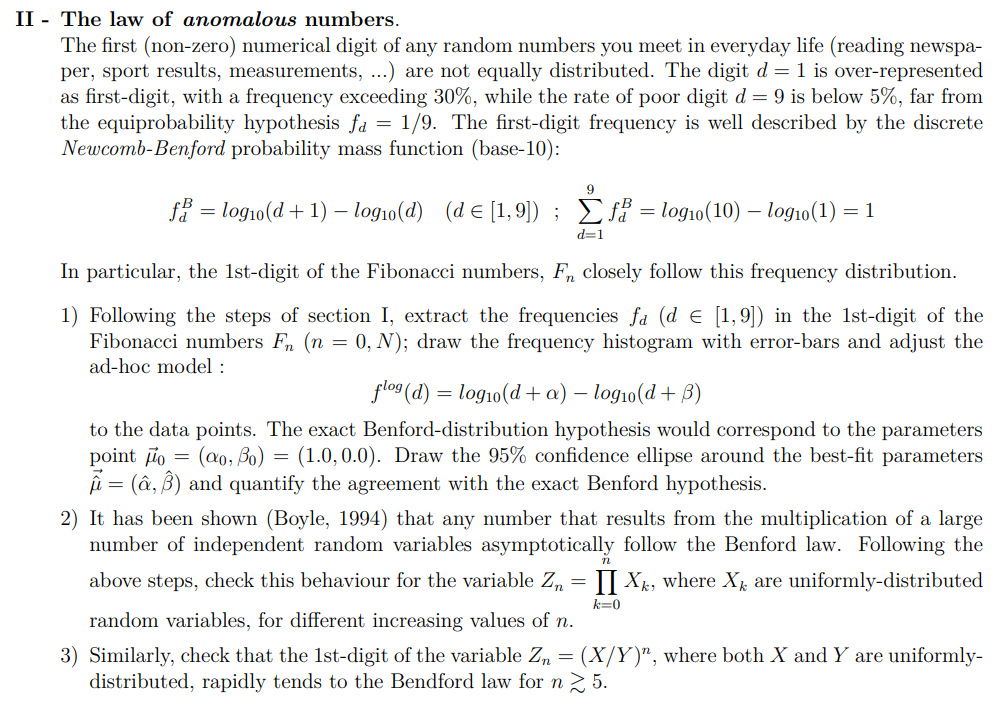

In [31]:
fibo = DigitFrequencyAnalyzer(SequenceSource.fibonacci()).run()
frequencies = fibo.f

Frequency histogram

In [32]:
def add_hoc_model(d, alpha, beta):

    return np.log10(d + alpha) - np.log10(d + beta)

popt, cov = curve_fit(add_hoc_model, fibo.d, fibo.f, p0=(1.0, 0.0), sigma=fibo.sigma, absolute_sigma=True)

/tmp/ipykernel_1768/2246961143.py:3: RuntimeWarning: divide by zero encountered in log10
  return np.log10(d + alpha) - np.log10(d + beta)
/tmp/ipykernel_1768/2246961143.py:5: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, cov = curve_fit(add_hoc_model, fibo.d, fibo.f, p0=(1.0, 0.0), sigma=fibo.sigma, absolute_sigma=True)


/tmp/ipykernel_1768/2246961143.py:3: RuntimeWarning: divide by zero encountered in log10
  return np.log10(d + alpha) - np.log10(d + beta)


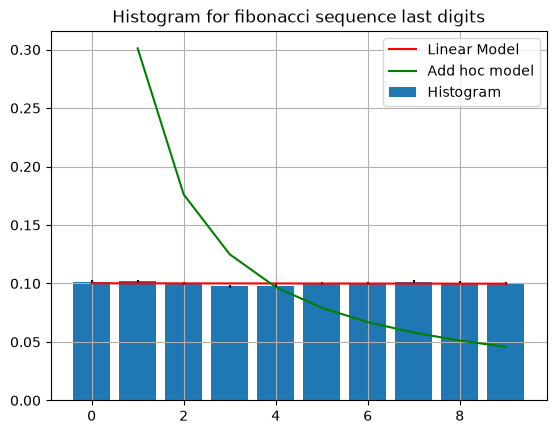

In [33]:
plt.grid()
plt.title("Histogram for fibonacci sequence last digits")
plt.bar(fibo.d, fibo.f, yerr = fibo.sigma, label = "Histogram")
plt.plot(fibo.d, fibo.linear_model(fibo.d, *fibo.popt), c = "red", label = "Linear Model")
plt.plot(fibo.d, add_hoc_model(fibo.d, *popt), c = "Green", label = "Add hoc model")
plt.legend()

Ellipse

<Axes: title={'center': 'Fibonacci'}, xlabel='$\\alpha$', ylabel='$\\beta$'>

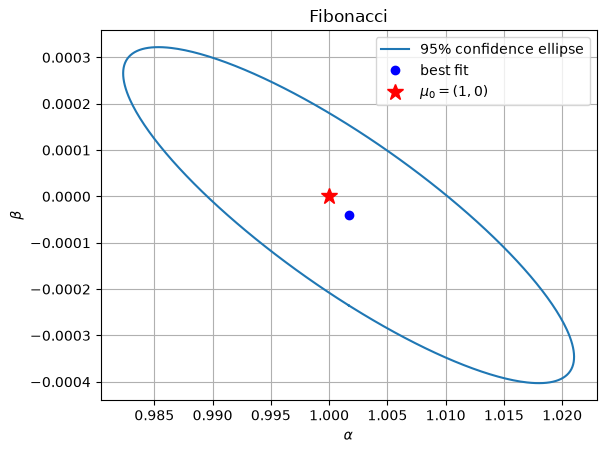

In [34]:
fibo.plot_ellipse()

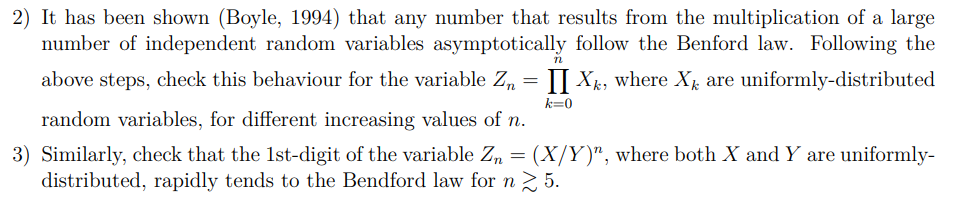

In [35]:
rng = np.random.default_rng(0)
M = 100000                                  
n = 10  


X_vec = rng.uniform(size=(M, n + 1))

z = X_vec.prod(axis=1)

z = np.array(z)

first_digit = np.array([int(f"{v}"[0]) for v in z])

first_digit

array([1, 2, 0, ..., 0, 4, 3], shape=(100000,))

In [36]:
count_z = np.bincount(first_digit)

In [37]:
count_z

array([31763, 17463, 11514,  8757,  7033,  5887,  5177,  4568,  4101,
        3737])

In [38]:
f_z = count_z/M
f_d = np.linspace(0, 9, 10)

<BarContainer object of 10 artists>

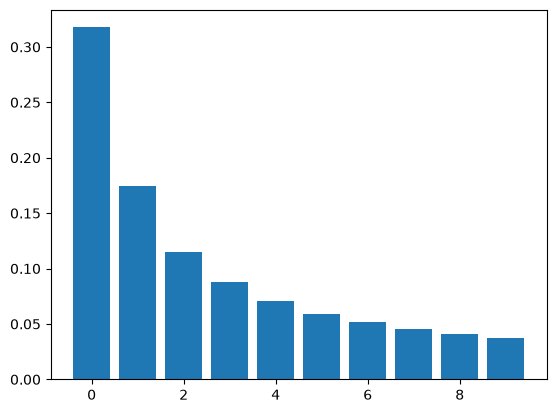

In [39]:
plt.bar(f_d, f_z)

In [88]:
class FrequencyAnalyzer:
    def __init__(self, vec):
        self.vec = vec
        self.d = np.arange(10)
        self.M = vec.shape[0]

    MU0 = np.array([1.0, 0.0])
    d = np.arange(10)
    
    @staticmethod
    def linear_model( alpha, beta, d=d):
        return alpha / 10.0 + beta * d

    def compute_frequency(self):
        count = np.bincount(self.vec)

        self.f = count / self.M

        self.sigma = np.sqrt(self.f * (1 - self.f) / self.M)

        return self.f, self.sigma

    def fit(self):
        """Least-squares fit of the linear model; returns best-fit values and covariance."""
        if self.f is None:                          # make sure frequencies exist first
            self.compute_frequencies()
        self.popt, self.cov = curve_fit(
            self.linear_model, self.d, self.f,
            p0=self.MU0, sigma=self.sigma, absolute_sigma=True,   # errors are real, not just weights
        )
        return self.popt, self.cov

    @property
    def parameter_variances(self):
        return self.fit()[0,0], self.fit()[1,1]

    @property
    def parameter_correlation(self):
        return (self.cov[0,1])/(np.sqrt(self.cov[0,0] * self.cov[1,1]))

    def compute_chi2(self):
    
        """Compute chi2_min, degrees of freedom and the p-value of the fit."""
        
        residuals = (self.f - self.linear_model(self.d, *self.popt)) / self.sigma
        self.chi2_min = np.sum(residuals ** 2)
        self.n_dof = len(self.d) - len(self.popt)   # 10 points - 2 parameters = 8
        self.p_value = chi2.sf(self.chi2_min, self.n_dof)   # survival function = P(chi2 > observed)
        return self.chi2_min, self.n_dof, self.p_value
    
    def delta_chi2(self, alpha, beta):
        """Delta chi2 = (p - p_hat)^T C^-1 (p - p_hat)."""
        diff = np.array([alpha, beta]) - self.popt  # distance from the best fit
        return diff @ np.linalg.inv(self.cov) @ diff

    def add_hoc_model(self, alpha, beta):

        return (np.log10(self.d + alpha) - np.log10(self.d + beta))

    def plot_histogram(self, ax=None):
        """Bar chart of f_d with error bars, the best-fit line and the 1/10 level."""
        ax = ax                        # use current axes if none is given
        ax.bar(self.d, self.f, yerr=self.sigma, capsize=3, alpha=0.7, label="data")
        ax.plot(self.d, self.linear_model(self.d, *self.popt), "r-o", ms=4, label="best-fit line")
        ax.axhline(0.1, color="k", ls="--", lw=1, label=r"$f_d = 1/10$")
        ax.set_xticks(self.d)
        ax.set_xlabel("d")
        ax.set_ylabel(r"$f_d$")
        ax.set_title(f"Digit frequencies: {self.source.name} (N={self.N})")
        ax.legend()
        return ax
    
    # contructing ellipse
    def ellipse_points(self, cl=0.95, n=400):
        """Return (alpha, beta) coordinates of the confidence ellipse at level cl.

        The ellipse axes come from the eigenvectors/eigenvalues of the covariance
        matrix; its size is set by the chi2 quantile for 2 parameters.
        """
        k = chi2.ppf(cl, 2)                         # Delta chi2 threshold (about 5.99 for 95%)
        eigval, eigvec = np.linalg.eigh(self.cov)               # eigenvectors = ellipse axes
        t = np.linspace(0, 2 * np.pi, n)
        unit_circle = np.vstack([np.cos(t), np.sin(t)])
        # stretch the unit circle along the axes, rotate it, then shift to the best fit
        pts = eigvec @ (np.sqrt(k * eigval)[:, None] * unit_circle)
        return self.popt[0] + pts[0], self.popt[1] + pts[1]
    
    def plot_ellipse(self, ax=None, cl=0.95):
        """Plot the confidence ellipse, the best-fit point and the hypothesis mu0."""
        ax = ax
        a, b = self.ellipse_points(cl)
        ax.plot(a, b, label=f"{int(cl*100)}% confidence ellipse")
        ax.plot(*self.popt, "bo", label="best fit")
        ax.plot(*self.MU0, "r*", ms=12, label=r"$\mu_0=(1,0)$")
        ax.set_xlabel(r"$\alpha$")
        ax.set_ylabel(r"$\beta$")
        ax.set_title(self.source.name)
        ax.grid(True)
        ax.legend()
        return ax

In [89]:
vec = FrequencyAnalyzer(first_digit)

In [90]:
vec_f, vec_sigma = vec.compute_frequency()
vec_parameter_values, cov_matrix_vec = vec.fit()

In [91]:
vec_linear = vec.linear_model(*vec_parameter_values)

In [93]:
vec_add_hoc = vec.add_hoc_model(*vec_parameter_values)
vec_add_hoc

/tmp/ipykernel_1768/3638136083.py:58: RuntimeWarning: invalid value encountered in log10
  return (np.log10(self.d + alpha) - np.log10(self.d + beta))


array([       nan, 0.89416365, 0.63051558, 0.49825601, 0.4151128 ,
       0.35703343, 0.31381464, 0.28024685, 0.25334771, 0.23127018])

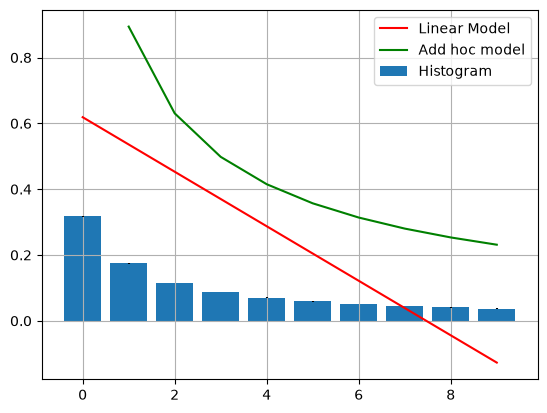

In [95]:
plt.grid()
plt.bar(vec.d, vec_f, yerr = vec_sigma, label = "Histogram")
plt.plot(vec.d, vec_linear, c = "red", label = "Linear Model")
plt.plot(vec.d, vec_add_hoc, c = "Green", label = "Add hoc model")
plt.legend()

In [66]:
count = np.bincount(first_digit)
count

array([31763, 17463, 11514,  8757,  7033,  5887,  5177,  4568,  4101,
        3737])